# Green Cavity v9: DIV 12 well 0 LFP H5

This notebook runs the integrated Green Cavity v9 candidate-type, edge-speed, gamma-phase, and Schur-mode analysis on the stim-removal-null DIV 12 well 0 LFP recording.

The recording is loaded from the same MaxTwo `data.raw.h5` structure used by `phase_waves.py`: `data0000` is resolved to the routed raw dataset, mapping coordinates are read from the recording settings, and voltage chunks are converted with the H5 `lsb` scale.

In [12]:

from pathlib import Path
import importlib.util
import json
import os
import sys
from types import SimpleNamespace

import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd().resolve()
if not (repo_root / "phase_waves.py").exists():
    repo_root = repo_root.parent.resolve()
if not (repo_root / "phase_waves.py").exists():
    raise FileNotFoundError("Run this notebook from the repo root or Notebooks/ so phase_waves.py can be imported.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

_mpl_config_dir = repo_root / "outputs" / ".matplotlib"
_mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_config_dir))

import phase_waves

REPO_ROOT = repo_root
SCRIPT_CANDIDATES = [
    REPO_ROOT / "green_cavity_v9_integrated.py",
    REPO_ROOT / "scripts" / "green_cavity_v9_integrated.py",
    Path("/Users/danielrebbin/Downloads/green_cavity_v9_integrated/green_cavity_v9_integrated.py"),
]
SCRIPT_PATH = next((path for path in SCRIPT_CANDIDATES if path.exists()), SCRIPT_CANDIDATES[-1])

# LFP source switch copied from phase_waves_hdmea_lfp.ipynb.
# `DATASET` can be a well number ("0"), a data_store alias ("data0000"), or a full raw dataset path.
LFP_SOURCE = "stim_removal_null_lfp"  # "stim_removal_null_lfp", "raw_h5_control_2", or "custom_h5"
DIV = 12
WELL = 0
DATASET_OVERRIDE = None
LFP_FILE_OVERRIDE = None

RAW_H5_CONTROL_2_FILE = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/ephaptic_stimulation_caspfiguration_control_2.raw.h5")
STIM_REMOVAL_NULL_LFP_ROOT = Path("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull")


def dataset_for_well(well):
    return f"data{int(well):04d}"


def resolve_lfp_file(source, div, *, override=None):
    if override is not None:
        return Path(override).expanduser()
    if source == "stim_removal_null_lfp":
        candidates = [
            STIM_REMOVAL_NULL_LFP_ROOT / f"DIV {int(div)}" / "data.raw.h5",
            STIM_REMOVAL_NULL_LFP_ROOT / f"DIV{int(div)}" / "data.raw.h5",
        ]
    elif source == "raw_h5_control_2":
        candidates = [RAW_H5_CONTROL_2_FILE]
    elif source == "custom_h5":
        raise ValueError("Set LFP_FILE_OVERRIDE when LFP_SOURCE='custom_h5'.")
    else:
        raise ValueError("LFP_SOURCE must be 'stim_removal_null_lfp', 'raw_h5_control_2', or 'custom_h5'.")
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No LFP H5 file found. Tried:\n" + "\n".join(str(c) for c in candidates))


FILE = resolve_lfp_file(LFP_SOURCE, DIV, override=LFP_FILE_OVERRIDE)
DATASET = DATASET_OVERRIDE or dataset_for_well(WELL)
OUTDIR = REPO_ROOT / "outputs" / "green_cavity_v9" / f"{LFP_SOURCE}_well{int(WELL)}_DIV{int(DIV)}_h5"

assert SCRIPT_PATH.exists(), f"Missing Green Cavity implementation: {SCRIPT_PATH}"
# This also validates the data_store alias/full-path dataset and finds routed/all_channels raw.
H5_INFO = phase_waves.inspect_file(FILE, DATASET)
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"repo root:      {REPO_ROOT}")
print(f"implementation: {SCRIPT_PATH}")
print(f"lfp h5:         {FILE}")
print(f"dataset:        {DATASET} -> {H5_INFO['raw_path']}")
print(f"sampling:       {H5_INFO['fs_raw']:.1f} Hz")
print(f"raw shape:      {H5_INFO['raw_shape']}")
print(f"mapped sites:   {H5_INFO['n_mapped_channels']}")
print(f"output:         {OUTDIR}")


repo root:      /Users/danielrebbin/Documents/GitHub/ephax
implementation: /Users/danielrebbin/Downloads/green_cavity_v9_integrated/green_cavity_v9_integrated.py
lfp h5:         /Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull/DIV 12/data.raw.h5
dataset:        data0000 -> /data_store/data0000/groups/routed/raw
sampling:       10000.0 Hz
raw shape:      (1020, 6000200)
mapped sites:   1020
output:         /Users/danielrebbin/Documents/GitHub/ephax/outputs/green_cavity_v9/stim_removal_null_lfp_well0_DIV12_h5



## Analysis Parameters

The Green Cavity script expects an in-memory active-channel array. The adapter below keeps the input flexible and memory-bounded: it uses `phase_waves.inspect_file()` / `phase_waves.load_chunk()` to resolve MaxTwo `data_store` aliases (`0`, `data0000`, full raw paths), scores active channels on a short H5 window, then reloads only the selected channels for the requested analysis interval.

For ephaptic/subthreshold propagation, active-channel selection is based on **band-limited LFP/gamma amplitude** with spatial balancing, not high-frequency spike-like power. This keeps the selected electrode set closer to a field readout. For a fast smoke run, reduce `h5_duration_s`, `n_active`, `max_events`, or `max_iter`. Set `h5_duration_s = None` only when you really want the full recording in memory after active-channel selection.


In [13]:

params = dict(
    # Original script API fields. The H5 adapter below uses input_npz as the H5 file path.
    input_npz=str(FILE),
    outdir=str(OUTDIR),
    n_active=500,
    target_lfp_fs=1000.0,
    band_low=30.0,
    band_high=50.0,
    max_events=10,
    k_fast=6,
    k_field=4,
    k_neigh=16,
    n_patches=6,
    core_size=14,
    halo_size=48,
    top_modes=5,
    max_iter=3,
    verbose=True,
    # H5-specific adapter settings.
    h5_dataset=DATASET,
    h5_start_s=0.0,
    h5_duration_s=120.0,  # set to None for the full recording after active-channel selection
    h5_active_score_start_s=0.0,
    h5_active_score_duration_s=30.0,
    # LFP/ephaptic-oriented active-channel selection.
    h5_active_selection_mode="gamma_spatial",  # "gamma_spatial", "gamma", or "variance"
    h5_active_band_low=30.0,
    h5_active_band_high=50.0,
    h5_active_score_fs=500.0,
    h5_spatial_bins_x=8,
    h5_spatial_bins_y=4,
)

args = SimpleNamespace(**params)
params


{'input_npz': '/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/LFP/stimRemovalNull/DIV 12/data.raw.h5',
 'outdir': '/Users/danielrebbin/Documents/GitHub/ephax/outputs/green_cavity_v9/stim_removal_null_lfp_well0_DIV12_h5',
 'n_active': 500,
 'target_lfp_fs': 1000.0,
 'band_low': 30.0,
 'band_high': 50.0,
 'max_events': 10,
 'k_fast': 6,
 'k_field': 4,
 'k_neigh': 16,
 'n_patches': 6,
 'core_size': 14,
 'halo_size': 48,
 'top_modes': 5,
 'max_iter': 3,
 'verbose': True,
 'h5_dataset': 'data0000',
 'h5_start_s': 0.0,
 'h5_duration_s': 120.0,
 'h5_active_score_start_s': 0.0,
 'h5_active_score_duration_s': 30.0,
 'h5_active_selection_mode': 'gamma_spatial',
 'h5_active_band_low': 30.0,
 'h5_active_band_high': 50.0,
 'h5_active_score_fs': 500.0,
 'h5_spatial_bins_x': 8,
 'h5_spatial_bins_y': 4}

## Load Implementation

In [14]:
spec = importlib.util.spec_from_file_location("green_cavity_v9_integrated", SCRIPT_PATH)
green_cavity_v9 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(green_cavity_v9)

# Keep notebook output interactive. The source script forces the Agg backend for CLI use,
# but its plotting functions still write PNGs to OUTDIR.
print("Loaded:", green_cavity_v9.__file__)

Loaded: /Users/danielrebbin/Downloads/green_cavity_v9_integrated/green_cavity_v9_integrated.py


## H5 Loader Adapter

This mirrors the `phase_waves` loading path: resolve the recording dataset, read the routed raw chunk through `phase_waves.load_chunk()`, use the H5 mapping coordinates, then perform the same active-channel selection and downsampling expected by the Green Cavity script.

In [15]:

h5_info = phase_waves.inspect_file(FILE, args.h5_dataset)
h5_info


{'raw_path': '/data_store/data0000/groups/routed/raw',
 'recording_group': '/data_store/data0000',
 'raw_shape': (1020, 6000200),
 'n_mapped_channels': 1020,
 'fs_raw': 10000.0,
 'lsb': 6.29425039733178e-06,
 'x_um_min': 17.5,
 'x_um_max': 3797.5,
 'y_um_min': 17.5,
 'y_um_max': 2082.5}

In [16]:

def _bounded_h5_frames(info, start_s, duration_s):
    fs_raw = float(info["fs_raw"])
    total_frames = int(info["raw_shape"][1])
    start_frame = int(round(max(0.0, float(start_s)) * fs_raw))
    start_frame = min(start_frame, total_frames)
    if duration_s is None:
        stop_frame = total_frames
    else:
        stop_frame = min(total_frames, start_frame + int(round(max(0.0, float(duration_s)) * fs_raw)))
    n_frames = max(0, stop_frame - start_frame)
    return start_frame, n_frames


def _spatially_balanced_top(score, coords_um, n_active, *, bins_x=8, bins_y=4):
    """Select high-scoring channels while keeping coverage across the HD-MEA footprint."""
    score = np.asarray(score, dtype=float)
    coords_um = np.asarray(coords_um, dtype=float)
    n_active = min(int(n_active), score.size)
    finite = np.isfinite(score) & np.all(np.isfinite(coords_um), axis=1)
    if n_active <= 0 or not np.any(finite):
        return np.array([], dtype=int)

    global_order = [int(i) for i in np.argsort(np.nan_to_num(score, nan=-np.inf))[::-1] if finite[i]]
    bins_x = max(1, int(bins_x))
    bins_y = max(1, int(bins_y))
    if bins_x == 1 and bins_y == 1:
        return np.array(sorted(global_order[:n_active]), dtype=int)

    x = coords_um[:, 0]
    y = coords_um[:, 1]
    x_edges = np.linspace(np.nanmin(x[finite]), np.nanmax(x[finite]), bins_x + 1)
    y_edges = np.linspace(np.nanmin(y[finite]), np.nanmax(y[finite]), bins_y + 1)
    x_bin = np.clip(np.searchsorted(x_edges, x, side="right") - 1, 0, bins_x - 1)
    y_bin = np.clip(np.searchsorted(y_edges, y, side="right") - 1, 0, bins_y - 1)

    bin_members = []
    for by in range(bins_y):
        for bx in range(bins_x):
            members = np.flatnonzero(finite & (x_bin == bx) & (y_bin == by))
            if members.size:
                members = members[np.argsort(score[members])[::-1]]
                bin_members.append(list(map(int, members)))
    if not bin_members:
        return np.array(sorted(global_order[:n_active]), dtype=int)

    per_bin = max(1, int(np.ceil(n_active / len(bin_members))))
    selected = []
    selected_set = set()
    for members in bin_members:
        for idx in members[:per_bin]:
            if idx not in selected_set:
                selected.append(idx)
                selected_set.add(idx)
            if len(selected) >= n_active:
                return np.array(sorted(selected), dtype=int)
    for idx in global_order:
        if idx not in selected_set:
            selected.append(idx)
            selected_set.add(idx)
        if len(selected) >= n_active:
            break
    return np.array(sorted(selected), dtype=int)


def _gamma_lfp_score(raw_v, fs_raw, *, low_hz, high_hz, fs_score):
    """Score channels by narrowband LFP amplitude, avoiding spike-band selection bias."""
    nyq = 0.5 * float(fs_raw)
    low_hz = float(low_hz)
    high_hz = float(high_hz)
    if not (0.0 < low_hz < high_hz < nyq):
        raise ValueError(f"Active-selection band must be within 0-{nyq:g} Hz; got {low_hz}-{high_hz} Hz.")
    fs_score = min(float(fs_score), float(fs_raw))
    band = phase_waves.bandpass_downsample(
        raw_v,
        float(fs_raw),
        low_hz,
        high_hz,
        fs_score,
        max_channels_per_block=128,
    )
    analytic = green_cavity_v9.sig.hilbert(band, axis=0)
    amp = np.abs(analytic)
    amp_score = np.nanmedian(amp, axis=0)
    phase_lock = np.abs(np.nanmean(analytic / np.maximum(amp, np.finfo(np.float32).tiny), axis=0))
    # Amplitude is the main criterion. The weak phase-lock factor downweights channels with unstable/noisy phase.
    return amp_score * np.sqrt(np.clip(np.nan_to_num(phase_lock, nan=0.0), 0.0, 1.0))


def load_active_h5(path, n_active, target_fs):
    """Green Cavity adapter backed by phase_waves MaxTwo chunk loading."""
    path = Path(path)
    info = phase_waves.inspect_file(path, args.h5_dataset)
    fs_raw = float(info["fs_raw"])

    score_start_frame, score_n_frames = _bounded_h5_frames(
        info,
        getattr(args, "h5_active_score_start_s", args.h5_start_s),
        getattr(args, "h5_active_score_duration_s", 30.0),
    )
    if score_n_frames <= 0:
        raise ValueError("Requested H5 active-channel scoring window is empty")

    score_v, score_coords_mm, score_fs, score_mapping = phase_waves.load_chunk(
        path,
        args.h5_dataset,
        score_start_frame,
        score_n_frames,
    )
    if score_v.size == 0:
        raise ValueError("No mapped LFP channels were loaded for active-channel scoring")

    mode = str(getattr(args, "h5_active_selection_mode", "gamma_spatial")).lower()
    coords_score_um = np.asarray(score_coords_mm, dtype=float) * 1000.0
    if mode in {"gamma", "gamma_spatial", "lfp", "lfp_gamma"}:
        channel_score = _gamma_lfp_score(
            score_v,
            score_fs,
            low_hz=getattr(args, "h5_active_band_low", args.band_low),
            high_hz=getattr(args, "h5_active_band_high", args.band_high),
            fs_score=getattr(args, "h5_active_score_fs", 500.0),
        )
        if "spatial" in mode:
            active_score_idx = _spatially_balanced_top(
                channel_score,
                coords_score_um,
                n_active,
                bins_x=getattr(args, "h5_spatial_bins_x", 8),
                bins_y=getattr(args, "h5_spatial_bins_y", 4),
            )
        else:
            active_score_idx = np.sort(np.argsort(np.nan_to_num(channel_score, nan=-np.inf))[-min(int(n_active), channel_score.size):])
        selection_label = f"{mode} {getattr(args, 'h5_active_band_low', args.band_low):g}-{getattr(args, 'h5_active_band_high', args.band_high):g} Hz"
    elif mode == "variance":
        score_uv = (np.asarray(score_v, dtype=np.float32) - np.nanmedian(score_v, axis=0, keepdims=True)) * 1e6
        channel_score = np.nanvar(np.nan_to_num(score_uv, copy=False), axis=0)
        active_score_idx = np.sort(np.argsort(np.nan_to_num(channel_score, nan=-np.inf))[-min(int(n_active), channel_score.size):])
        selection_label = "variance only"
    else:
        raise ValueError("h5_active_selection_mode must be 'gamma_spatial', 'gamma', or 'variance'.")

    active_channels = np.asarray(score_mapping["channel"], dtype=int)[active_score_idx]

    start_frame, n_frames = _bounded_h5_frames(info, args.h5_start_s, args.h5_duration_s)
    if n_frames <= 0:
        raise ValueError("Requested H5 analysis window is empty")
    raw_v, coords_mm, fs_raw, mapping = phase_waves.load_chunk(
        path,
        args.h5_dataset,
        start_frame,
        n_frames,
        channels=active_channels,
    )
    if raw_v.size == 0:
        raise ValueError("No active LFP channels were loaded for the analysis window")

    uv = (np.asarray(raw_v, dtype=np.float32) - np.nanmedian(raw_v, axis=0, keepdims=True)) * 1e6
    uv = np.nan_to_num(uv, copy=False).astype(np.float32, copy=False)
    t = float(args.h5_start_s) + np.arange(uv.shape[0], dtype=float) / float(fs_raw)
    pos = np.asarray(coords_mm, dtype=float) * 1000.0

    decim = max(1, int(round(float(fs_raw) / float(target_fs))))
    fs_lfp = float(fs_raw) / decim
    lfp = green_cavity_v9.sig.resample_poly(uv, up=1, down=decim, axis=0).astype(np.float32).T
    tl = float(t[0]) + np.arange(lfp.shape[1], dtype=float) / fs_lfp
    idx = np.asarray(mapping.get("electrode", mapping["channel"]), dtype=int)

    print(
        f"Loaded H5 window {t[0]:.2f}-{t[-1]:.2f} s from {args.h5_dataset}: "
        f"{uv.shape[1]} active channels selected by {selection_label}, "
        f"raw fs={fs_raw:.1f} Hz, lfp fs={fs_lfp:.1f} Hz"
    )
    return uv, t, fs_raw, lfp, tl, fs_lfp, pos, idx


# Route the original script's run() through the phase_waves H5 loader.
green_cavity_v9.load_active = load_active_h5
print("Patched green_cavity_v9.load_active -> load_active_h5")


Patched green_cavity_v9.load_active -> load_active_h5


## Run Green Cavity v9

In [17]:
metrics = green_cavity_v9.run(args)
metrics_path = OUTDIR / "green_cavity_v9_metrics.json"
outputs_path = OUTDIR / "green_cavity_v9_outputs.npz"

print(json.dumps(metrics, indent=2))
print(f"metrics: {metrics_path}")
print(f"outputs: {outputs_path}")

Loaded H5 window 0.00-120.00 s from data0000: 500 active channels selected by gamma_spatial 30-50 Hz, raw fs=10000.0 Hz, lfp fs=1000.0 Hz
{
  "iteration": 1,
  "pf_lambda": 0.9297954689071071,
  "cF": 31.81818181815321,
  "cE": 7.500000000002253,
  "mean_loop": 0.003468553455685302
}
{
  "iteration": 2,
  "pf_lambda": 0.9301190119954225,
  "cF": 31.948916436159266,
  "cE": 7.539230729986591,
  "mean_loop": 0.003208790003740205
}
{
  "iteration": 3,
  "pf_lambda": 0.9304122990752184,
  "cF": 32.30769230767931,
  "cE": 7.539230729988734,
  "mean_loop": 0.0032303627399355877
}
{
  "n_active": 500,
  "events_used": 10,
  "event_times_s": [
    16.1603,
    17.2545,
    18.1366,
    40.3376,
    61.8446,
    63.6306,
    82.5117,
    82.6947,
    104.5679,
    106.2982
  ],
  "event_family_labels": [
    1,
    1,
    2,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "speed_scales_empirical": {
    "cF": 32.30769230767931,
    "cE": 7.539230729988734,
    "cminF": 15.67198239931265,

## Summary Metrics

In [18]:
summary_keys = [
    "n_active",
    "events_used",
    "speed_scales_empirical",
    "pf_lambda_final",
    "fast_speed_quantiles_mm_s",
    "gamma_speed_quantiles_mm_s",
    "fast_candidate_entropy_mean",
    "field_candidate_entropy_mean",
    "mean_schur_mode_mass",
    "mean_cross_support",
]
summary = {key: metrics.get(key) for key in summary_keys}
pd.json_normalize(summary).T.rename(columns={0: "value"})

,value
n_active,500
events_used,10
pf_lambda_final,0.930628
fast_speed_quantiles_mm_s,"[27.138557987373737, 28.632577760660336, 29.53..."
gamma_speed_quantiles_mm_s,"[5.1085821745246305, 12.284572937031482, 21.39..."
fast_candidate_entropy_mean,1.443909
field_candidate_entropy_mean,1.319648
mean_schur_mode_mass,0.004013
mean_cross_support,0.002169
speed_scales_empirical.cF,32.307692


## Event Families

In [19]:
family_metrics = pd.DataFrame(metrics.get("family_metrics", []))
family_metrics

,family,n_events,fast_median,gamma_median
0,1,9,29.568985,22.133059
1,2,1,29.347951,40.857981


## Saved Figures

/Users/danielrebbin/Documents/GitHub/ephax/outputs/green_cavity_v9/stim_removal_null_lfp_well0_DIV12_h5/green_cavity_v9_spatial.png


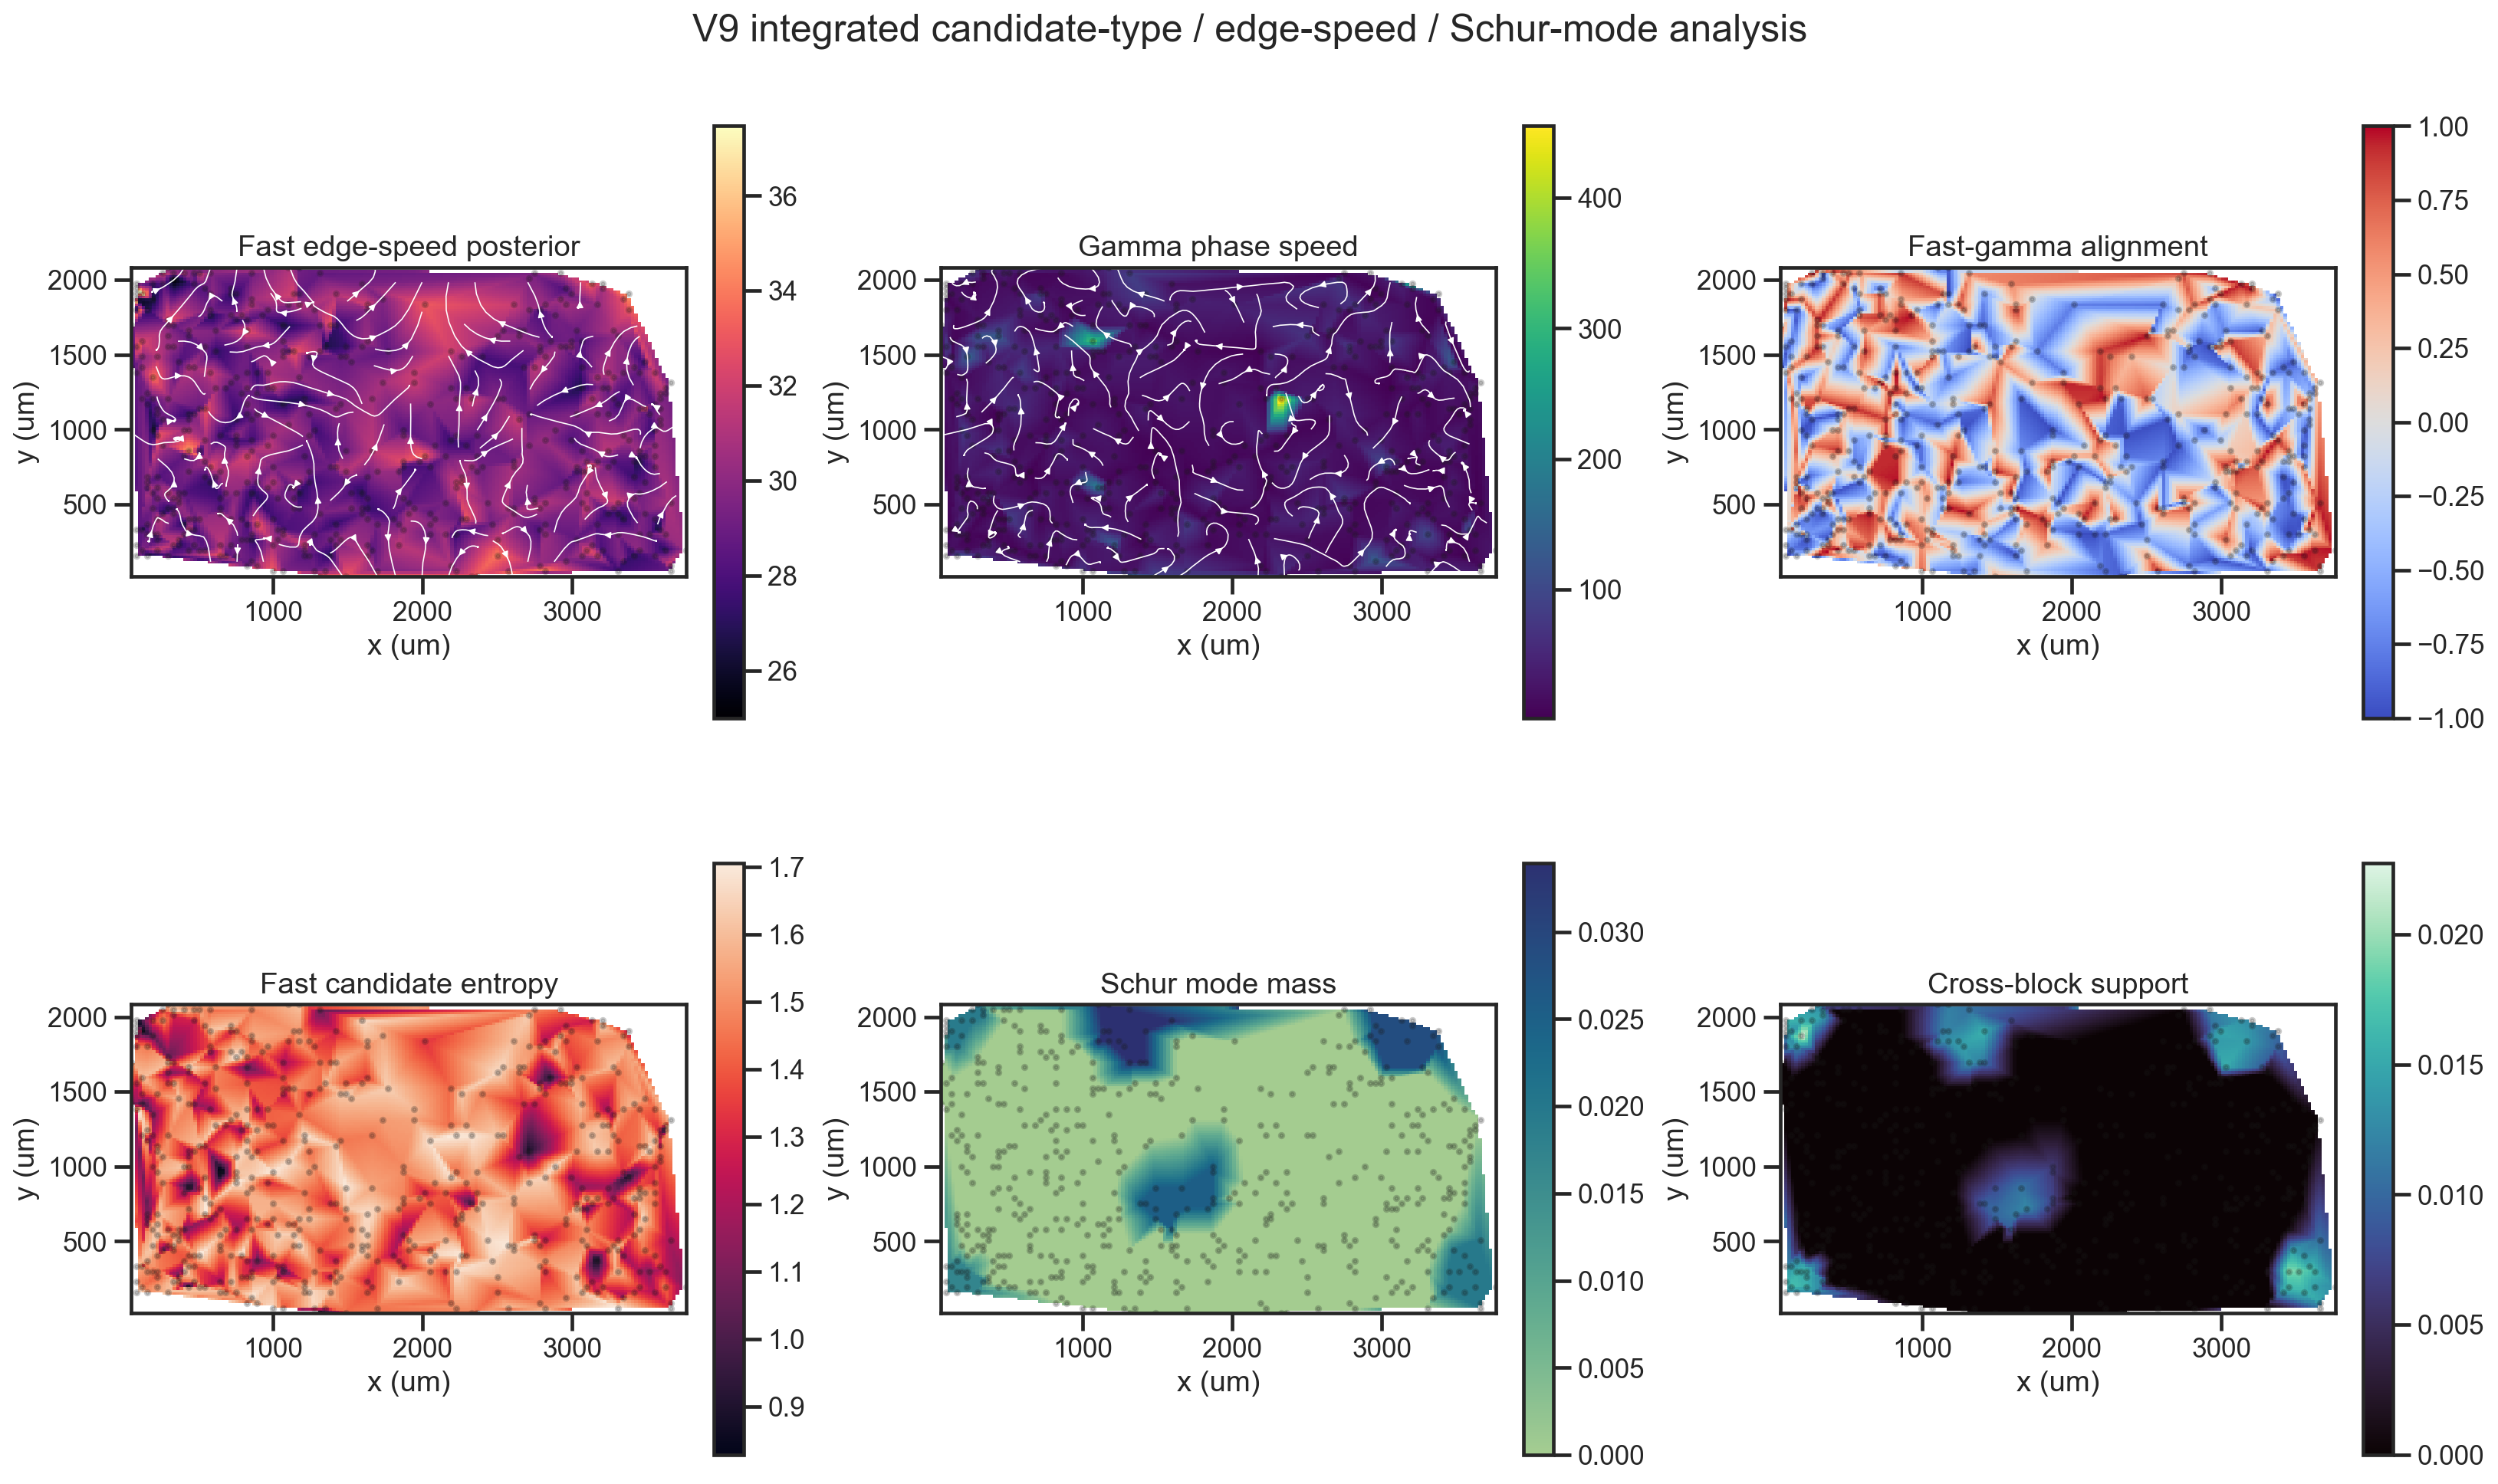

/Users/danielrebbin/Documents/GitHub/ephax/outputs/green_cavity_v9/stim_removal_null_lfp_well0_DIV12_h5/green_cavity_v9_diagnostics.png


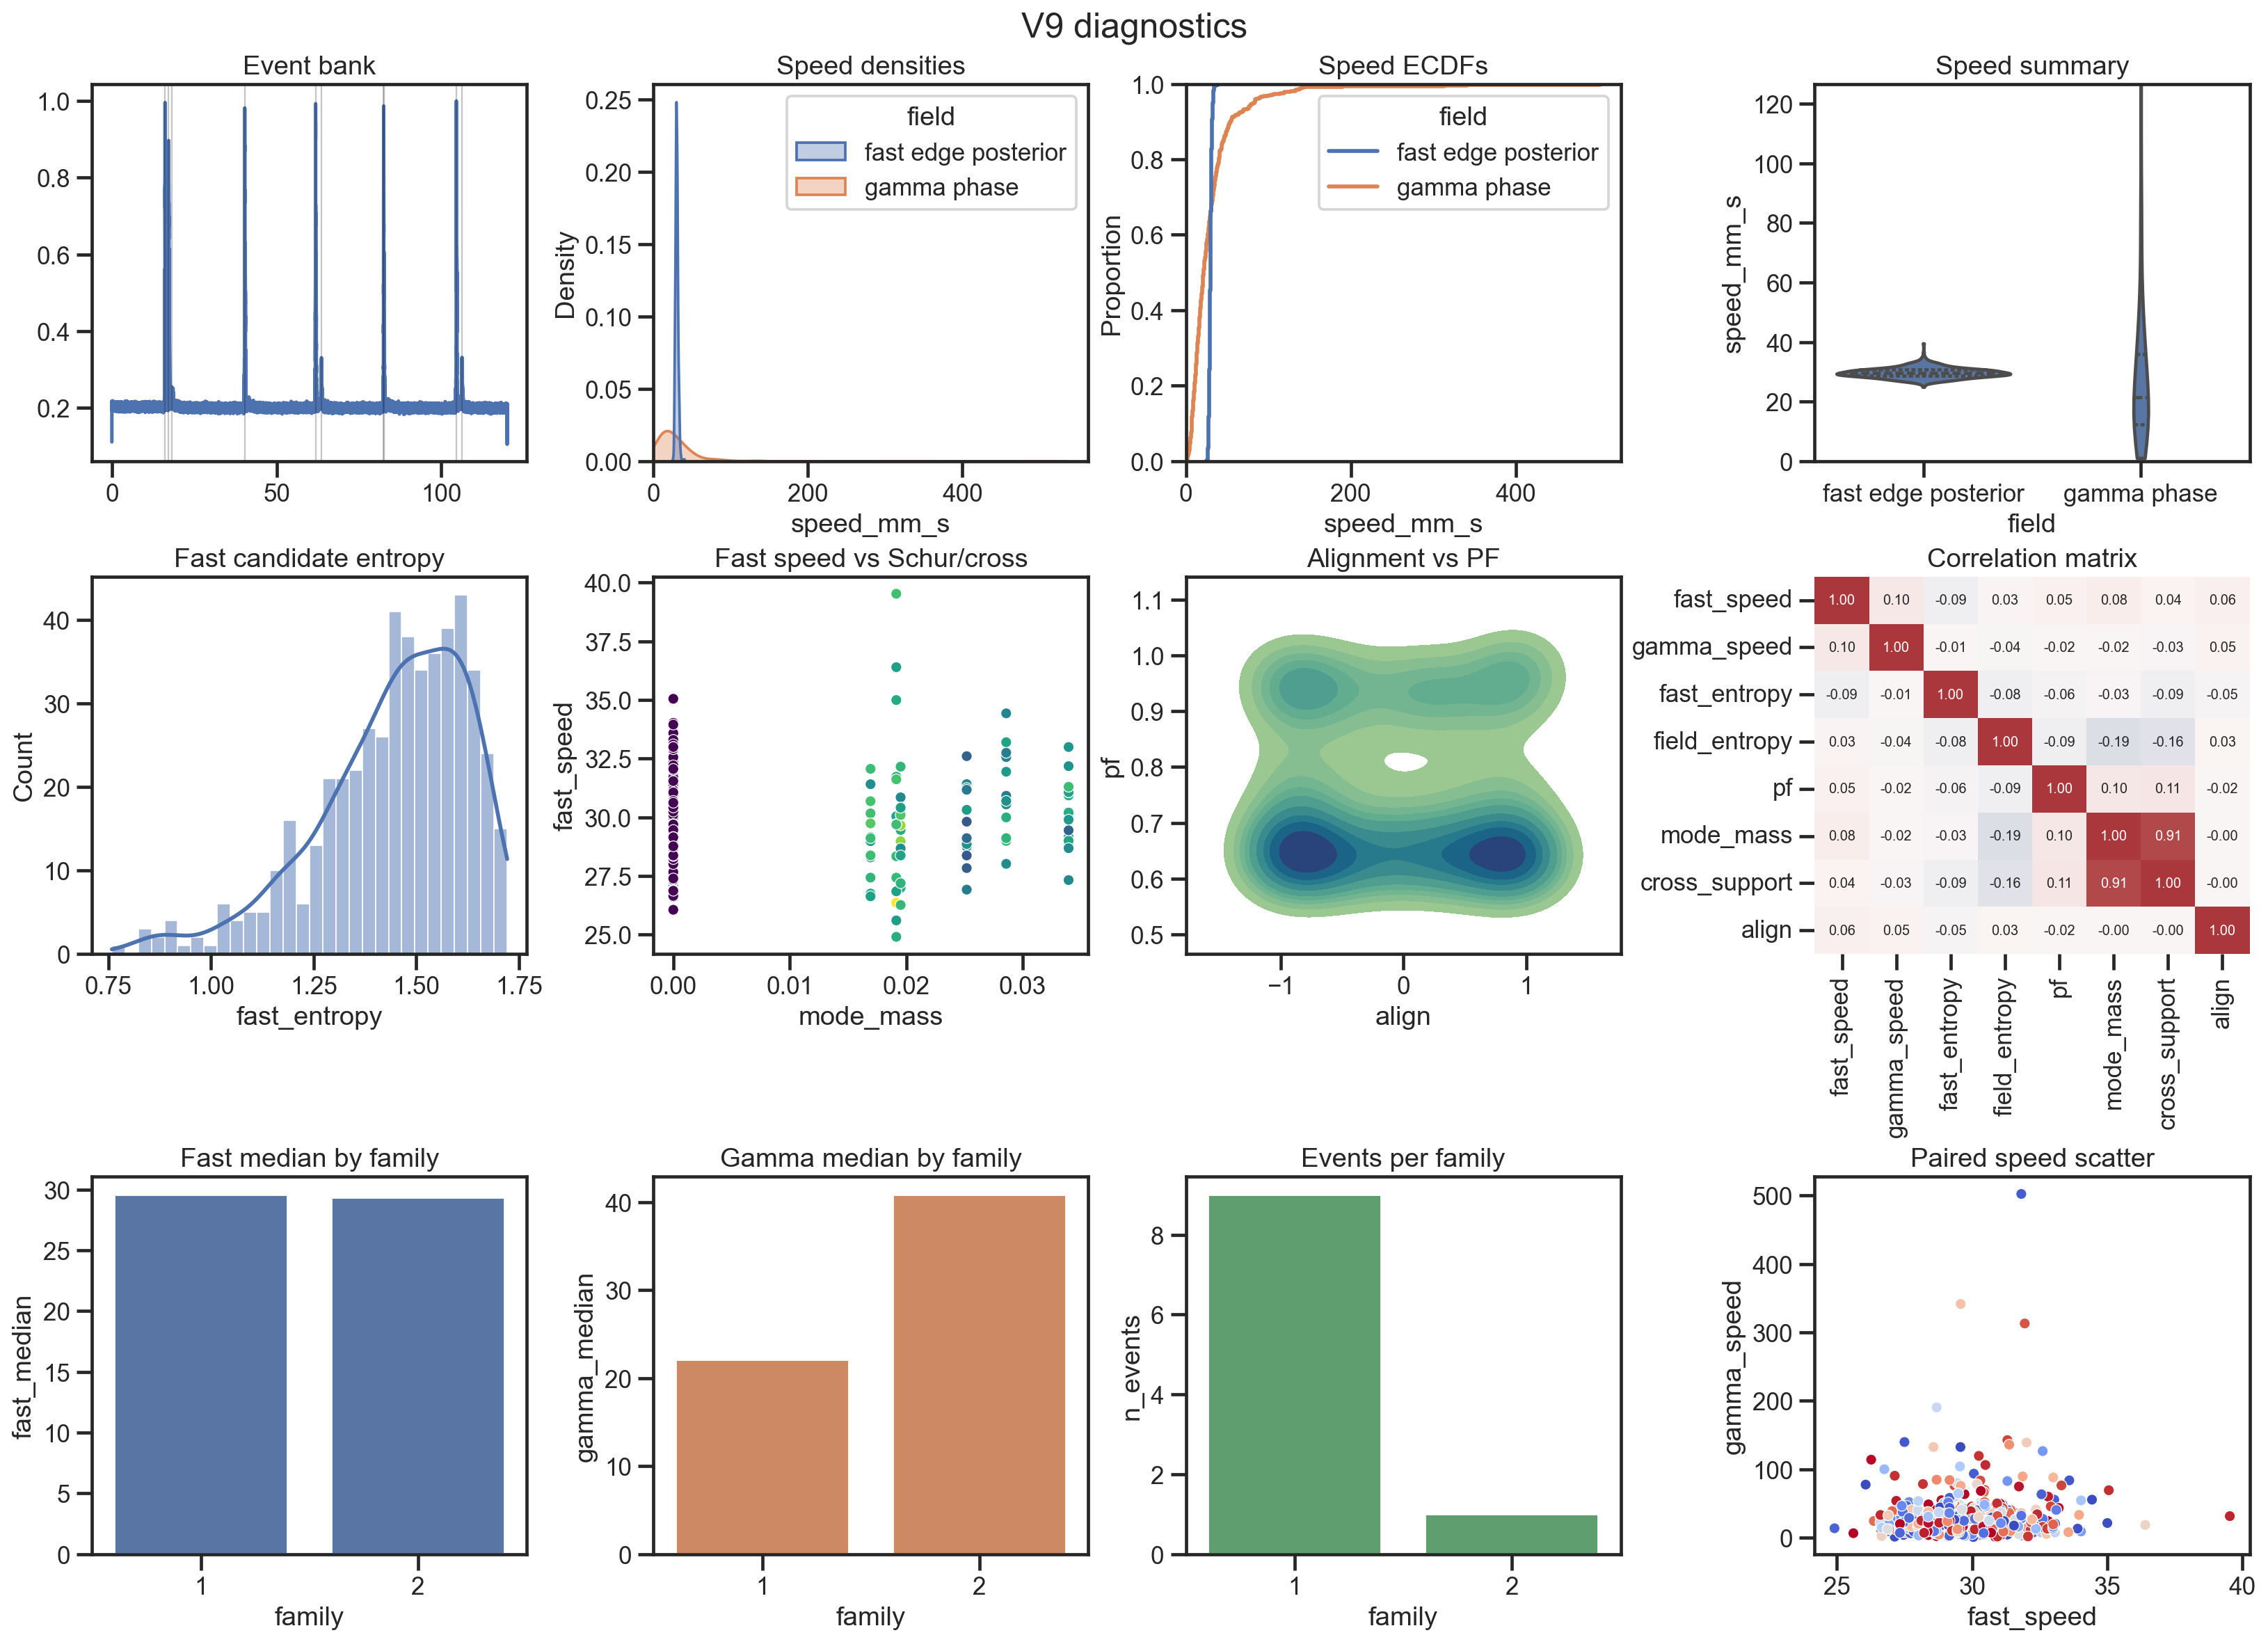

In [20]:
spatial_png = OUTDIR / "green_cavity_v9_spatial.png"
diagnostics_png = OUTDIR / "green_cavity_v9_diagnostics.png"

for png in [spatial_png, diagnostics_png]:
    if png.exists():
        print(png)
        display(Image(filename=str(png)))
    else:
        print(f"Missing: {png}")

## Load Saved Arrays

Use this cell for downstream inspection without rerunning the full analysis.

In [21]:
outputs = np.load(OUTDIR / "green_cavity_v9_outputs.npz", allow_pickle=True)
print("arrays:", sorted(outputs.files))

pos = outputs["pos"]
fast_speed = outputs["fast_speed"]
gamma_speed = outputs["gamma_speed"]

pd.DataFrame({
    "x_um": pos[:, 0],
    "y_um": pos[:, 1],
    "fast_speed_mm_s": fast_speed,
    "gamma_speed_mm_s": gamma_speed,
    "pf": outputs["pf"],
    "mode_mass": outputs["mode_mass"],
    "cross_support": outputs["cross_support"],
}).head()

arrays: ['AF', 'AG', 'E', 'QE', 'QF', 'TE', 'TF', 'Waa', 'Wap', 'Wpp', 'cross_support', 'entropyE', 'entropyF', 'event_times', 'fast_q05', 'fast_q95', 'fast_rel', 'fast_speed', 'fast_vec', 'gamma_rel', 'gamma_speed', 'gamma_vec', 'idx_active', 'labels', 'loop', 'metrics', 'mode_mass', 'pf', 'pos', 'type_post']


,x_um,y_um,fast_speed_mm_s,gamma_speed_mm_s,pf,mode_mass,cross_support
0,2887.5,997.5,29.881246,17.837943,0.868025,0.0,0.0
1,3587.5,1207.5,30.248421,17.459021,0.923850,0.0,0.0
2,3167.5,1347.5,31.008684,33.530969,0.922480,0.0,0.0
3,262.5,1067.5,28.997041,20.416102,0.607428,0.0,0.0
4,2152.5,822.5,29.166667,12.083068,0.746644,0.0,0.0
